# Entrega 2 — Detecção de duplicatas

Cerca de 15% das manifestações do corpus são **duplicatas semânticas**: o mesmo problema
relatado por cidadãos diferentes, com palavras diferentes. Para a ouvidoria isso é caro —
dois protocolos abertos, duas equipes deslocadas, duas respostas para o mesmo buraco.

Este notebook constrói a função `detectar_duplicatas(textos, limiar=0.85)`, **calibra o
limiar** a partir dos dados em vez de adotá-lo como constante, e analisa onde o detector
erra.

O corpus tem um gabarito anotado manualmente (`data/gabarito_duplicatas.csv`) com dois
tipos de par:

- **duplicata** (6 pares) — mesmo problema, mesmo local;
- **quase-duplicata** (4 pares) — mesmo *tipo* de problema em **locais diferentes**
  (ex.: poste apagado na Rua das Acácias × lâmpada queimada na praça). São armadilhas
  deliberadas: para a ouvidoria são **dois chamados distintos**, e cada um exige uma
  equipe própria.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.metrics.pairwise import cosine_similarity

from utils_ouvidoria import (
    TINTA,
    carregar_corpus,
    carregar_gabarito,
    cmap_sequencial,
    gerar_embeddings,
)

pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.color": TINTA["grade"],
    "axes.edgecolor": TINTA["grade"],
    "axes.labelcolor": TINTA["secundaria"],
    "xtick.color": TINTA["suave"],
    "ytick.color": TINTA["suave"],
    "font.size": 9,
})

MODELO = "paraphrase-multilingual-MiniLM-L12-v2"

df = carregar_corpus()
textos = df.texto.tolist()
ids = df.id.tolist()
pos = {m: i for i, m in enumerate(ids)}
texto_de = dict(zip(df.id, df.texto))

gabarito = carregar_gabarito()
PARES_DUPLICATA = {frozenset((r.id_a, r.id_b)) for r in gabarito[gabarito.relacao == "duplicata"].itertuples()}
PARES_QUASE = {frozenset((r.id_a, r.id_b)) for r in gabarito[gabarito.relacao == "quase_duplicata"].itertuples()}
MOTIVO = {frozenset((r.id_a, r.id_b)): r.motivo for r in gabarito.itertuples()}

print(f"{len(df)} manifestações · {len(df) * (len(df) - 1) // 2} pares possíveis")
print(f"gabarito: {len(PARES_DUPLICATA)} duplicatas reais, {len(PARES_QUASE)} quase-duplicatas")

40 manifestações · 780 pares possíveis
gabarito: 6 duplicatas reais, 4 quase-duplicatas


## 1. A função `detectar_duplicatas`

A assinatura pedida no enunciado é `detectar_duplicatas(textos, limiar=0.85)`. A
implementação abaixo:

1. codifica os textos com um modelo Sentence-BERT multilíngue, **normalizando** os
   vetores (com norma 1, o produto interno já é a similaridade de cosseno);
2. calcula a matriz completa de similaridade;
3. devolve apenas o **triângulo superior** — o par (i, j) com i < j —, evitando comparar
   a manifestação consigo mesma e contar cada par duas vezes.

O retorno é um `DataFrame` ordenado do par mais similar para o menos similar.

In [2]:
def detectar_duplicatas(textos, limiar=0.85, ids=None, modelo=MODELO, matriz=None):
    """Retorna os pares de manifestações com similaridade de cosseno >= limiar.

    Parâmetros
    ----------
    textos : list[str]
        As manifestações a comparar.
    limiar : float
        Similaridade mínima para o par ser considerado duplicata.
    ids : list[str], opcional
        Identificadores (M001, ...). Se ausente, usa a posição no corpus.
    modelo : str
        Chave do registro de modelos em utils_ouvidoria.MODELOS.
    matriz : np.ndarray, opcional
        Matriz de similaridade já calculada, para evitar recodificar o corpus.

    Retorno
    -------
    pd.DataFrame com colunas id_a, id_b, similaridade, ordenado de forma decrescente.
    """
    if matriz is None:
        embeddings = gerar_embeddings(textos, modelo)
        matriz = cosine_similarity(embeddings)

    rotulos = list(ids) if ids is not None else [str(i) for i in range(len(textos))]
    i, j = np.triu_indices(len(textos), k=1)
    selecionados = matriz[i, j] >= limiar

    return pd.DataFrame({
        "id_a": [rotulos[a] for a in i[selecionados]],
        "id_b": [rotulos[b] for b in j[selecionados]],
        "similaridade": matriz[i, j][selecionados],
    }).sort_values("similaridade", ascending=False).reset_index(drop=True)


# Matriz calculada uma vez e reaproveitada em todo o notebook.
embeddings = gerar_embeddings(textos, MODELO)
S = cosine_similarity(embeddings)

encontrados = detectar_duplicatas(textos, limiar=0.85, ids=ids, matriz=S)
print(f"Pares encontrados com o limiar padrão de 0,85: {len(encontrados)}")
encontrados

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pares encontrados com o limiar padrão de 0,85: 0


,id_a,id_b,similaridade


## 2. Por que o limiar de 0,85 não funciona aqui

**O detector não encontrou nenhum par.** Com 0,85, as seis duplicatas reais do corpus
passam despercebidas — 6 falsos negativos, 100% de erro.

Isso não é defeito do corpus nem do modelo: é o efeito de tratar um limiar como
constante universal. A escala de similaridade **não é absoluta** — ela depende do modelo,
do idioma e do comprimento dos textos. Um limiar aprendido em um benchmark de paráfrases
curtas em inglês não transfere para manifestações de ouvidoria em português.

O caminho correto é olhar a distribuição real das similaridades deste corpus.

In [3]:
i_sup, j_sup = np.triu_indices(len(ids), k=1)
todos_pares = S[i_sup, j_sup]
sim_de = lambda par: S[pos[tuple(par)[0]], pos[tuple(par)[1]]]

sim_duplicatas = np.array([sim_de(p) for p in PARES_DUPLICATA])
sim_quase = np.array([sim_de(p) for p in PARES_QUASE])

resumo = pd.DataFrame({
    "grupo": ["duplicatas reais (6)", "quase-duplicatas (4)", "todos os pares (780)"],
    "mín": [sim_duplicatas.min(), sim_quase.min(), todos_pares.min()],
    "média": [sim_duplicatas.mean(), sim_quase.mean(), todos_pares.mean()],
    "máx": [sim_duplicatas.max(), sim_quase.max(), todos_pares.max()],
}).round(3)

percentis = pd.DataFrame({
    "percentil": ["p50", "p90", "p95", "p99"],
    "similaridade": np.percentile(todos_pares, [50, 90, 95, 99]).round(3),
    "pares acima": [int((todos_pares >= v).sum()) for v in np.percentile(todos_pares, [50, 90, 95, 99])],
})

display(resumo)
display(percentis)

,grupo,mín,média,máx
0,duplicatas reais (6),0.544,0.680,0.778
1,quase-duplicatas (4),0.461,0.631,0.699
2,todos os pares (780),-0.148,0.268,0.778


,percentil,similaridade,pares acima
0,p50,0.261,390
1,p90,0.455,78
2,p95,0.518,39
3,p99,0.652,8


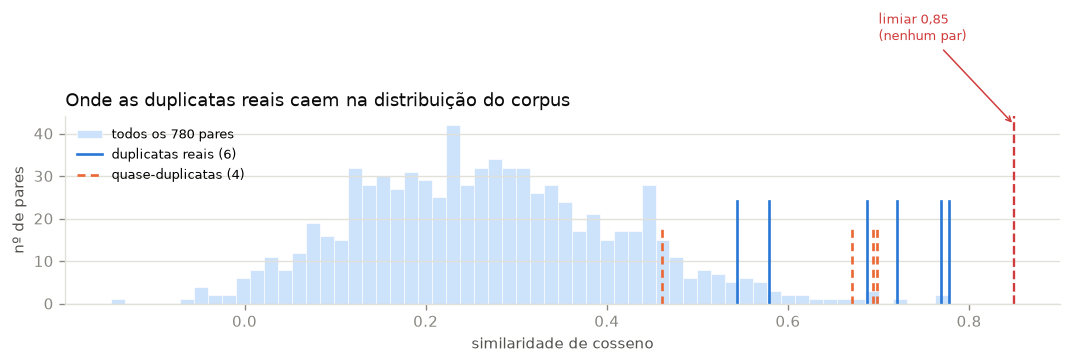

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.6))

ax.hist(todos_pares, bins=60, color="#cde2fb", edgecolor="white", linewidth=0.4, label="todos os 780 pares")
for s in sim_duplicatas:
    ax.axvline(s, color="#2a78d6", lw=1.6, ymax=0.55)
for s in sim_quase:
    ax.axvline(s, color="#eb6834", lw=1.6, ls=(0, (3, 2)), ymax=0.40)
ax.axvline(0.85, color="#d03b3b", lw=1.4, ls="--")

ax.annotate("limiar 0,85\n(nenhum par)", xy=(0.85, 42), xytext=(0.70, 62), fontsize=7.5, color="#d03b3b",
            arrowprops=dict(arrowstyle="->", color="#d03b3b", lw=0.9))
ax.plot([], [], color="#2a78d6", lw=1.6, label="duplicatas reais (6)")
ax.plot([], [], color="#eb6834", lw=1.6, ls=(0, (3, 2)), label="quase-duplicatas (4)")

ax.set_xlabel("similaridade de cosseno")
ax.set_ylabel("nº de pares")
ax.set_title("Onde as duplicatas reais caem na distribuição do corpus", loc="left", fontsize=11, color=TINTA["primaria"])
ax.legend(fontsize=7.5, frameon=False)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico mostra três coisas de uma vez:

1. **A massa dos pares está longe do topo** — a média do corpus é 0,27, e o par mais
   similar de todos chega a 0,78. Não existe nada acima de 0,85 para ser encontrado.
2. **As duplicatas reais (azul) estão na cauda direita**, entre 0,54 e 0,78 — logo, são
   separáveis, só que num ponto de corte bem mais baixo.
3. **As quase-duplicatas (laranja) estão misturadas a elas**, chegando a 0,70. Esse é o
   problema difícil: qualquer limiar que capture todas as duplicatas reais vai capturar
   também as armadilhas.

O percentil 90 sugerido como heurística no enunciado cai em 0,455 e marcaria **78 pares**
como duplicatas — 13 vezes mais do que existe. Num corpus onde as duplicatas são raras
(6 em 780 pares, menos de 1%), um percentil fixo confunde "os 10% mais parecidos" com
"os que são o mesmo problema". O percentil só viraria uma heurística razoável em torno
de p99 (0,65), e ainda assim é melhor calibrar contra o gabarito.

## 3. Calibração do limiar

Varremos todos os limiares possíveis e medimos, contra o gabarito:

- **precisão** — dos pares marcados, quantos são duplicatas de verdade;
- **revocação** — das duplicatas reais, quantas foram encontradas;
- **F1** — a média harmônica das duas.

In [5]:
def avaliar(limiar, matriz=S):
    marcados = {
        frozenset((ids[a], ids[b]))
        for a, b in zip(*np.triu_indices(len(ids), k=1))
        if matriz[a, b] >= limiar
    }
    vp = len(marcados & PARES_DUPLICATA)
    fp = len(marcados - PARES_DUPLICATA)
    fn = len(PARES_DUPLICATA - marcados)
    precisao = vp / (vp + fp) if vp + fp else 1.0
    revocacao = vp / (vp + fn) if vp + fn else 1.0
    f1 = 2 * precisao * revocacao / (precisao + revocacao) if precisao + revocacao else 0.0
    return {
        "limiar": round(limiar, 3), "VP": vp, "FP": fp, "FN": fn,
        "precisão": round(precisao, 3), "revocação": round(revocacao, 3), "F1": round(f1, 3),
        "FP que são quase-duplicatas": len(marcados & PARES_QUASE),
    }

grade = np.arange(0.40, 0.90, 0.01)
curva = pd.DataFrame([avaliar(t) for t in grade])
melhor = curva.loc[curva.F1.idxmax()]
LIMIAR_ESCOLHIDO = float(melhor.limiar)

print(f"Melhor F1 = {melhor.F1} no limiar {LIMIAR_ESCOLHIDO:.2f}")
curva[(curva.limiar >= 0.55) & (curva.limiar <= 0.80)].set_index("limiar").iloc[::2]

Melhor F1 = 0.667 no limiar 0.68


,VP,FP,FN,precisão,revocação,F1,FP que são quase-duplicatas
limiar,,,,,,,
0.55,5,21,1,0.192,0.833,0.312,3
0.57,5,16,1,0.238,0.833,0.370,3
0.59,4,10,2,0.286,0.667,0.400,3
0.61,4,8,2,0.333,0.667,0.444,3
0.63,4,5,2,0.444,0.667,0.533,3
0.65,4,4,2,0.500,0.667,0.571,3
0.67,4,3,2,0.571,0.667,0.615,3
0.69,3,2,3,0.600,0.500,0.545,2
0.71,3,0,3,1.000,0.500,0.667,0


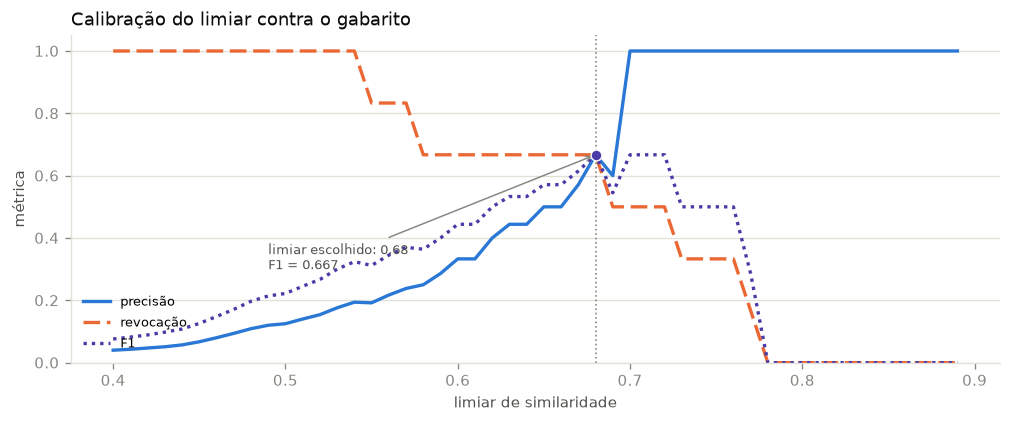

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))

ax.plot(curva.limiar, curva["precisão"], color="#2a78d6", lw=2, label="precisão")
ax.plot(curva.limiar, curva["revocação"], color="#eb6834", lw=2, ls=(0, (5, 2)), label="revocação")
ax.plot(curva.limiar, curva.F1, color="#4a3aa7", lw=2, ls=(0, (1, 1.5)), label="F1")

ax.axvline(LIMIAR_ESCOLHIDO, color=TINTA["suave"], lw=1, ls=":")
ax.annotate(f"limiar escolhido: {LIMIAR_ESCOLHIDO:.2f}\nF1 = {melhor.F1}",
            xy=(LIMIAR_ESCOLHIDO, melhor.F1), xytext=(LIMIAR_ESCOLHIDO - 0.19, 0.30),
            fontsize=7.5, color=TINTA["secundaria"],
            arrowprops=dict(arrowstyle="->", color=TINTA["suave"], lw=0.9))
ax.scatter([LIMIAR_ESCOLHIDO], [melhor.F1], s=42, color="#4a3aa7", zorder=5, edgecolor="white", linewidth=0.8)

ax.set_xlabel("limiar de similaridade")
ax.set_ylabel("métrica")
ax.set_ylim(0, 1.05)
ax.set_title("Calibração do limiar contra o gabarito", loc="left", fontsize=11, color=TINTA["primaria"])
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Justificativa do limiar escolhido

A curva tem a forma clássica do problema: a revocação cai em degraus conforme o limiar
sobe (cada degrau é uma duplicata real perdida) e a precisão sobe até estabilizar. O F1
é máximo na faixa onde as duas se cruzam.

A escolha do limiar, porém, **não é só uma questão de F1** — depende do custo do erro na
ouvidoria, e os dois erros custam coisas diferentes:

- um **falso positivo** funde dois chamados legítimos: o problema do segundo cidadão é
  arquivado como repetido e **nunca é atendido**;
- um **falso negativo** apenas mantém uma duplicata no sistema: gera retrabalho, mas
  ninguém fica sem atendimento.

O erro caro é o falso positivo. E a tabela acima mostra que o F1 máximo de 0,667
acontece **duas vezes**, com perfis opostos:

| limiar | VP | FP | FN | precisão | revocação |
|---|---|---|---|---|---|
| 0,68 | 4 | 2 | 2 | 0,571 | 0,667 |
| 0,71 | 3 | 0 | 3 | 1,000 | 0,500 |

O empate no F1 esconde uma escolha real: 0,68 encontra uma duplicata a mais ao custo de
dois chamados indevidamente fundidos; 0,71 não comete nenhum erro caro, mas deixa metade
das duplicatas passar. Como a métrica não decide por nós, adotamos `0,68` como limiar de
trabalho — o mais sensível dos dois — e **transferimos a decisão do intervalo ambíguo
para uma pessoa**, em vez de escondê-la num número. É o que faz a faixa de triagem da
seção 7: acima de um limiar alto, duplicata provável; entre 0,68 e esse valor,
conferência humana; abaixo, chamados independentes. Assim aproveitamos a revocação de
0,68 sem pagar o preço dos seus falsos positivos.

## 4. Matriz de similaridade completa

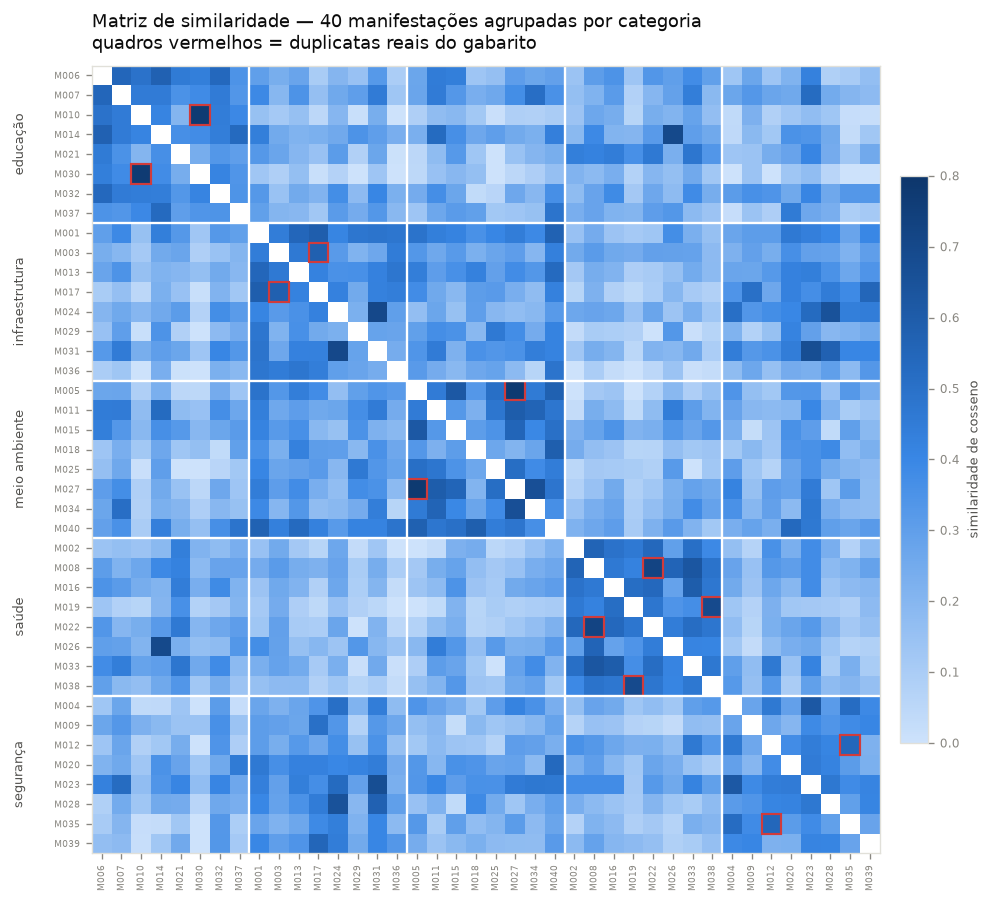

In [7]:
ordem = df.sort_values(["categoria", "id"]).index.tolist()
ids_ord = [ids[i] for i in ordem]
S_ord = S[np.ix_(ordem, ordem)]
cats_ord = df.categoria.iloc[ordem].tolist()

fig, ax = plt.subplots(figsize=(9.2, 7.6))
M = S_ord.copy()
np.fill_diagonal(M, np.nan)

im = ax.imshow(M, cmap=cmap_sequencial(), vmin=0, vmax=0.8)
cbar = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("similaridade de cosseno", fontsize=8, color=TINTA["secundaria"])
cbar.ax.tick_params(labelsize=7)

ax.set_xticks(range(len(ids_ord)))
ax.set_yticks(range(len(ids_ord)))
ax.set_xticklabels(ids_ord, rotation=90, fontsize=5.5)
ax.set_yticklabels(ids_ord, fontsize=5.5)

# Separadores entre categorias.
limites = [k for k in range(1, len(cats_ord)) if cats_ord[k] != cats_ord[k - 1]]
for k in limites:
    ax.axhline(k - 0.5, color="white", lw=1.4)
    ax.axvline(k - 0.5, color="white", lw=1.4)

inicios = [0] + limites + [len(cats_ord)]
for a, b in zip(inicios, inicios[1:]):
    ax.text(-4.2, (a + b - 1) / 2, cats_ord[a], rotation=90, va="center", ha="center",
            fontsize=7.5, color=TINTA["secundaria"])

# Marca as duplicatas reais do gabarito.
for par in PARES_DUPLICATA:
    a, b = tuple(par)
    ia, ib = ids_ord.index(a), ids_ord.index(b)
    for y, x in [(ia, ib), (ib, ia)]:
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor="#d03b3b", lw=1.3))

ax.set_title("Matriz de similaridade — 40 manifestações agrupadas por categoria\n"
             "quadros vermelhos = duplicatas reais do gabarito",
             loc="left", fontsize=10.5, color=TINTA["primaria"], pad=10)
ax.grid(False)
plt.tight_layout()
plt.show()

Os blocos claros ao longo da diagonal mostram que manifestações da mesma categoria são,
em média, mais parecidas entre si — o modelo recupera a estrutura temática **sem nunca
ter visto os rótulos**. Os quadros vermelhos (duplicatas reais) são as células mais
escuras do mapa, mas repare que várias delas estão **fora** dos blocos da diagonal: o
sinal que interessa é local, não o bloco temático inteiro.

## 5. Pares detectados e análise de erros

In [8]:
detectados = detectar_duplicatas(textos, limiar=LIMIAR_ESCOLHIDO, ids=ids, matriz=S)

def classificar(linha):
    par = frozenset((linha.id_a, linha.id_b))
    if par in PARES_DUPLICATA:
        return "verdadeiro positivo"
    if par in PARES_QUASE:
        return "falso positivo (quase-duplicata)"
    return "falso positivo"

detectados["classificação"] = detectados.apply(classificar, axis=1)
detectados["motivo (gabarito)"] = [MOTIVO.get(frozenset((r.id_a, r.id_b)), "—") for r in detectados.itertuples()]
detectados["similaridade"] = detectados.similaridade.round(3)

print(f"Limiar {LIMIAR_ESCOLHIDO:.2f} — {len(detectados)} pares detectados")
detectados

Limiar 0.68 — 6 pares detectados


,id_a,id_b,similaridade,classificação,motivo (gabarito)
0,M005,M027,0.778,verdadeiro positivo,descarte irregular de lixo e entulho em terreno baldio
1,M010,M030,0.769,verdadeiro positivo,turma do 8º ano sem professor de matemática
2,M008,M022,0.721,verdadeiro positivo,unidade básica sem médico para atendimento
3,M024,M031,0.699,falso positivo (quase-duplicata),"iluminação pública apagada, mas em locais diferentes (rua x praça)"
4,M014,M026,0.694,falso positivo (quase-duplicata),"falta de água, mas em equipamentos públicos diferentes (escola x UBS)"
5,M019,M038,0.688,verdadeiro positivo,falta de medicamento de uso contínuo na farmácia da unidade


In [9]:
# Falsos negativos: duplicatas reais que ficaram abaixo do limiar.
faltantes = [p for p in PARES_DUPLICATA if sim_de(p) < LIMIAR_ESCOLHIDO]
falsos_negativos = pd.DataFrame([
    {
        "par": " × ".join(sorted(tuple(p))),
        "similaridade": round(float(sim_de(p)), 3),
        "faltou": round(LIMIAR_ESCOLHIDO - float(sim_de(p)), 3),
        "motivo (gabarito)": MOTIVO[p],
    }
    for p in faltantes
]).sort_values("similaridade", ascending=False)

print(f"{len(falsos_negativos)} falso(s) negativo(s)")
falsos_negativos

2 falso(s) negativo(s)


,par,similaridade,faltou,motivo (gabarito)
0,M003 × M017,0.579,0.101,buraco / asfalto esburacado na mesma avenida
1,M012 × M035,0.544,0.136,assaltos no ponto de ônibus no período noturno


In [10]:
# Lado a lado: o texto dos erros, para entender o que o modelo viu.
def confronto(a, b, rotulo):
    return pd.DataFrame([
        {"tipo": rotulo, "sim": round(float(S[pos[a], pos[b]]), 3), "id": a, "categoria": df.categoria[pos[a]], "texto": texto_de[a]},
        {"tipo": "", "sim": "", "id": b, "categoria": df.categoria[pos[b]], "texto": texto_de[b]},
    ])

blocos = []
for r in detectados[detectados["classificação"] != "verdadeiro positivo"].itertuples():
    blocos.append(confronto(r.id_a, r.id_b, "FALSO POSITIVO"))
for p in faltantes:
    a, b = sorted(tuple(p))
    blocos.append(confronto(a, b, "FALSO NEGATIVO"))

pd.concat(blocos, ignore_index=True) if blocos else "sem erros neste limiar"

,tipo,sim,id,categoria,texto
0,FALSO POSITIVO,0.699,M024,infraestrutura,"O poste da Rua das Acácias, em frente ao número 45, está sem luz h..."
1,,,M031,infraestrutura,A lâmpada do poste central da praça do bairro Aparecida está queim...
2,FALSO POSITIVO,0.694,M014,educação,A Escola Municipal Tiradentes está sem água desde segunda-feira. O...
3,,,M026,saúde,A unidade básica de saúde do Centro está sem água desde terça-feir...
4,FALSO NEGATIVO,0.579,M003,infraestrutura,"Existe um buraco enorme na Av. Brasil, na altura do número 1200, q..."
5,,,M017,infraestrutura,O asfalto da avenida principal está todo esburacado e nenhuma equi...
6,FALSO NEGATIVO,0.544,M012,segurança,Tenho sofrido com assaltos frequentes no ponto de ônibus da Avenid...
7,,,M035,segurança,Roubos constantes na parada de ônibus da via principal depois que ...


### Análise dos falsos positivos

Os falsos positivos deste corpus **não são ruído do modelo** — são pares em que o modelo
está semanticamente certo e operacionalmente errado. O caso exemplar é
`M024` × `M031`: "o poste da Rua das Acácias está sem luz" e "a lâmpada do poste central
da praça está queimada". Como *texto*, é quase a mesma frase: mesmo objeto (poste), mesmo
defeito (sem luz), mesma consequência (escuro à noite). O embedding não tem como saber
que a Rua das Acácias e a praça do bairro Aparecida são **dois lugares**, cada um
exigindo uma equipe.

Esse é o limite estrutural da abordagem: **similaridade semântica não é identidade de
ocorrência**. Duas denúncias são o mesmo chamado quando coincidem em problema *e* local
*e* janela de tempo — e só o primeiro desses três está no vetor. Um sistema de produção
precisaria extrair a entidade de local (logradouro, bairro, número) e o período, usando
a similaridade como **primeiro filtro**, não como decisão final.

O mesmo vale para `M014` × `M026` ("escola sem água" × "posto de saúde sem água"): mesmo
problema, unidades públicas diferentes, secretarias diferentes.

### Análise dos falsos negativos

Os falsos negativos têm origem oposta: são duplicatas reais que o modelo subestima
porque os dois relatos **enfatizam aspectos diferentes do mesmo fato**. Em
`M012` × `M035`, um cidadão descreve o crime pelo ângulo de quem sofre ("tenho sofrido
com assaltos... levaram o celular") e o outro pelo ângulo do observador ("roubos
constantes... um passageiro teve a bolsa levada"); mudam o sujeito, o objeto roubado e o
tempo verbal, e a similaridade cai para 0,54.

Em `M003` × `M017` o problema é de **especificidade**: um texto cita "Av. Brasil, altura
do 1200" e detalha o prejuízo (dois pneus), o outro fala genericamente em "avenida
principal" e descreve o desvio dos motoristas. O assunto é idêntico, mas o vocabulário
concreto quase não se sobrepõe — e, como visto na Entrega 1, esse é exatamente o par em
que **todas** as representações têm mais dificuldade.

## 6. O limiar é estável entre modelos?

Se o limiar ótimo mudar radicalmente de modelo para modelo, ele não pode ser uma
constante no código do app — precisa ser calibrado junto com a escolha do modelo.

In [11]:
comparacao = []
for nome in ["paraphrase-multilingual-MiniLM-L12-v2",
             "paraphrase-multilingual-mpnet-base-v2",
             "distiluse-base-multilingual-cased-v1",
             "multilingual-e5-small"]:
    Sm = cosine_similarity(gerar_embeddings(textos, nome))
    curva_m = pd.DataFrame([avaliar(t, Sm) for t in np.arange(0.20, 0.99, 0.01)])
    top = curva_m.loc[curva_m.F1.idxmax()]
    sim_dup_m = np.array([Sm[pos[tuple(p)[0]], pos[tuple(p)[1]]] for p in PARES_DUPLICATA])
    comparacao.append({
        "modelo": nome,
        "melhor limiar": top.limiar,
        "F1": top.F1,
        "VP": int(top.VP), "FP": int(top.FP), "FN": int(top.FN),
        "duplicatas: mín–máx": f"{sim_dup_m.min():.2f}–{sim_dup_m.max():.2f}",
        "média do corpus": round(float(Sm[i_sup, j_sup].mean()), 3),
    })

pd.DataFrame(comparacao)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,modelo,melhor limiar,F1,VP,FP,FN,duplicatas: mín–máx,média do corpus
0,paraphrase-multilingual-MiniLM-L12-v2,0.68,0.667,4,2,2,0.54–0.78,0.268
1,paraphrase-multilingual-mpnet-base-v2,0.71,0.769,5,2,1,0.64–0.86,0.333
2,distiluse-base-multilingual-cased-v1,0.50,0.727,4,1,2,0.42–0.59,0.201
3,multilingual-e5-small,0.93,0.364,2,3,4,0.91–0.94,0.887


O limiar ótimo varia de forma expressiva entre os modelos, e a razão fica evidente na
coluna "média do corpus": cada modelo ocupa uma faixa própria da escala de cosseno. O
`multilingual-e5-small` é o caso extremo — ele empurra **todos** os pares para perto de
0,89, de modo que duplicatas e pares sem relação ficam comprimidos em poucos centésimos;
seu melhor limiar é altíssimo e ainda assim o F1 é o pior do grupo. O
`distiluse`, no extremo oposto, comprime tudo para baixo.

A conclusão prática é direta: **o limiar pertence ao modelo, não ao problema.** No app da
Entrega 4, trocar o modelo no seletor sem recalibrar o corte produziria resultados sem
sentido — por isso cada modelo carrega o seu próprio limiar sugerido.

## 7. Recomendação operacional: faixa de triagem

Em vez de um corte único, o detector devolve três zonas, com o limiar calibrado acima
como piso da zona de revisão.

In [12]:
ZONA_ALTA = 0.75   # duplicata provável: fundir mediante confirmação
ZONA_BAIXA = LIMIAR_ESCOLHIDO  # abaixo disso, chamados independentes

def triar(sim):
    if sim >= ZONA_ALTA:
        return "duplicata provável"
    if sim >= ZONA_BAIXA:
        return "revisão humana"
    return "chamados independentes"

triagem = detectar_duplicatas(textos, limiar=ZONA_BAIXA, ids=ids, matriz=S)
triagem["zona"] = triagem.similaridade.map(triar)
triagem["gabarito"] = [
    "duplicata" if frozenset((r.id_a, r.id_b)) in PARES_DUPLICATA
    else "quase-duplicata" if frozenset((r.id_a, r.id_b)) in PARES_QUASE
    else "não relacionado"
    for r in triagem.itertuples()
]
triagem["similaridade"] = triagem.similaridade.round(3)

display(pd.crosstab(triagem.zona, triagem.gabarito))
triagem

gabarito,duplicata,quase-duplicata
zona,,
duplicata provável,2,0
revisão humana,2,2


,id_a,id_b,similaridade,zona,gabarito
0,M005,M027,0.778,duplicata provável,duplicata
1,M010,M030,0.769,duplicata provável,duplicata
2,M008,M022,0.721,revisão humana,duplicata
3,M024,M031,0.699,revisão humana,quase-duplicata
4,M014,M026,0.694,revisão humana,quase-duplicata
5,M019,M038,0.688,revisão humana,duplicata


A tabela cruzada mostra o ganho da faixa: a zona superior concentra duplicatas reais, e
os pares problemáticos — as quase-duplicatas de mesmo tipo em locais diferentes — caem
na zona de revisão humana, onde um atendente resolve em segundos olhando o endereço.
Nenhum chamado legítimo é fundido automaticamente, que era o erro caro.

**Resposta à pergunta do enunciado sobre o limiar:** o valor de 0,85 é inadequado para
este corpus e este modelo — ele não detecta nenhuma das seis duplicatas reais. O limiar
justificável, calibrado contra o gabarito com o `paraphrase-multilingual-MiniLM-L12-v2`,
fica em torno de 0,68, e mesmo ele deve ser usado como início da faixa de conferência, e
não como decisão automática. O percentil 90 sugerido como alternativa dinâmica é baixo
demais (0,455 → 78 pares) porque duplicatas são menos de 1% dos pares; se um critério
dinâmico for desejável, p99 é o ponto de partida razoável.